### 🔁 What is Iterative Retrieval in Agentic RAG?
Combined both Iterative And Self reflection

✅ Definition:
Iterative Retrieval is a dynamic strategy where an AI agent doesn't settle for the first batch of retrieved documents. Instead, it evaluates the adequacy of the initial context, and if necessary, it:

- Refines the query,
- Retrieves again,
- Repeats the process until it’s confident enough to answer the original question.

🧠 Why Use It?
In standard RAG:

- A single retrieval step is done, and the LLM uses it to answer.
- If the documents were incomplete or irrelevant, the answer may fail.

In Iterative RAG:

- The agent reflects on the retrieved content and the answer it produced.
- If it’s unsure, it can refine its search (like a human researcher would).

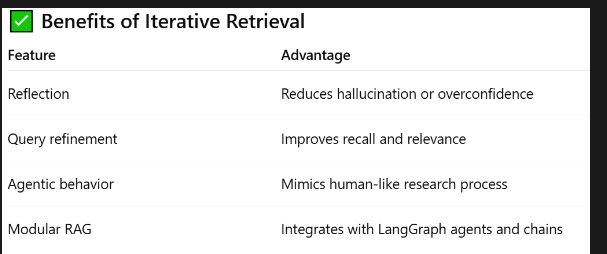

In [1]:
import os
from typing import List
from pydantic import BaseModel
from langchain.chat_models import init_chat_model
from langchain_openai import OpenAIEmbeddings
from langchain_classic.schema import Document
from langchain_classic.vectorstores import FAISS
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import StateGraph, END

In [2]:
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
llm=init_chat_model("ollama:llama3.2:latest")

In [3]:
### Load And Embed Documents
from langchain_ollama import OllamaEmbeddings
docs = TextLoader("sample_docs.txt", encoding="utf-8").load()
chunks = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50).split_documents(docs)
vectorstore = FAISS.from_documents(chunks, OllamaEmbeddings(model="llama3.2:latest"))
retriever = vectorstore.as_retriever()

In [4]:
### Define Agent State

class IterativeRAGState(BaseModel):
    question: str
    refined_question: str = ""
    retrieved_docs: List[Document] = []
    answer: str = ""
    verified: bool = False
    attempts: int = 0


In [5]:
### Retrieve Node
def retrieve_docs(state: IterativeRAGState) -> IterativeRAGState:
    query = state.refined_question or state.question
    docs = retriever.invoke(query)
    return state.model_copy(update={"retrieved_docs": docs})


In [6]:
### Reflect And Verify
def generate_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    context = "\n\n".join(doc.page_content for doc in state.retrieved_docs)
    prompt = f"""Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    response = llm.invoke(prompt.strip()).content.strip()
    return state.model_copy(update={"answer": response, "attempts": state.attempts + 1})

In [7]:
## Reflect on answer
def reflect_on_answer(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
Evaluate whether the answer below is factually sufficient and complete.

Question: {state.question}
Answer: {state.answer}

Respond 'YES' if it's complete, otherwise 'NO' with feedback.
"""
    feedback = llm.invoke(prompt).content.lower()
    verified = "yes" in feedback
    return state.model_copy(update={"verified": verified})


In [8]:
## Refine query
def refine_query(state: IterativeRAGState) -> IterativeRAGState:
    
    prompt = f"""
The answer appears incomplete. Suggest a better version of the query that would help retrieve more relevant context.

Original Question: {state.question}
Current Answer: {state.answer}
"""
    new_query = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"refined_question": new_query})


In [9]:
builder = StateGraph(IterativeRAGState)

builder.add_node("retrieve", retrieve_docs)
builder.add_node("answer", generate_answer)
builder.add_node("reflect", reflect_on_answer)
builder.add_node("refine", refine_query)

builder.set_entry_point("retrieve")
builder.add_edge("retrieve", "answer")
builder.add_edge("answer", "reflect")

builder.add_conditional_edges(
    "reflect",
    lambda s: END if s.verified or s.attempts >= 2 else "refine"
)

builder.add_edge("refine", "retrieve")
builder.add_edge("answer", END)

graph = builder.compile()


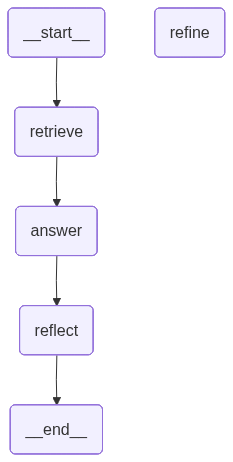

In [10]:
graph

In [11]:
query = "agent loops  and transformer-based systems?"

initial_state = IterativeRAGState(question=query)
final = graph.invoke(initial_state)

print("✅ Final Answer:\n", final["answer"])
print("\n🧠 Verified:", final["verified"])
print("🔁 Attempts:", final["attempts"])


✅ Final Answer:
 Transformer-based systems and agent-based architectures are two distinct concepts that can complement each other. Here's how they interact:

1. **Feedback Loop**: Agent loops, as mentioned in the context, rely on feedback to refine their actions. This is where transformer-based systems come into play. Transformers learn from large datasets through self-supervised learning, which provides a vast amount of feedback data for the agent loop. This feedback can help the agent improve its performance and adapt to new situations.

2. **Planning and Interaction**: Agent-based architectures benefit from memory, planning, and interaction with tools. Transformer-based systems also need these components to be effective in certain contexts. Transformers often rely on external pre-trained models as "tools" or "backbones" for specific tasks like language translation or image classification. These pre-trained models can provide the necessary planning and memory capabilities.

3. **Real

In [12]:
final

{'question': 'agent loops  and transformer-based systems?',
 'refined_question': 'Here\'s a revised version of the query that provides more context:\n\n"Can you provide an example of how agent loops are used in conjunction with transformer-based systems, such as transformers or transformer-like architectures? Are there any specific applications or domains where the combination of agent loops and transformer models has been particularly effective?"\n\nThis revised query suggests that the original question is looking for a concrete example or application of combining agent loops and transformer-based systems, rather than just providing general benefits. By adding more specificity, the query can help retrieve more relevant context and provide a clearer direction for the response.\n\nHere\'s an updated answer based on this revised query:\n\n"Agent loops have been successfully integrated with transformer-based systems in various applications, including:\n\n1. **Imitation learning**: Agent l

![image.png](attachment:image.png)